In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/Alzheimer_Project/archive (2).zip"

Streaming output truncated to the last 5000 lines.
  inflating: Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_102.jpg  
  inflating: Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_103.jpg  
  inflating: Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_104.jpg  
  inflating: Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_105.jpg  
  inflating: Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_106.jpg  
  inflating: Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_107.jpg  
  inflating: Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_108.jpg  
  inflating: Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_109.jpg  
  inflating: Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_110.jpg  
  inflating: Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_111.jpg  
  inflating: Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_112.jpg  
  inflating: Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_113.jpg  
  inflating: Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_114.jpg  
  inflating: Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_115.jpg  
  inflating

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# The correct path based on your image
original_dir = 'Data'

# Define the paths for our new, binary dataset
new_base_dir = 'alzheimer_binary'
new_train_dir = os.path.join(new_base_dir, 'train')
new_test_dir = os.path.join(new_base_dir, 'test')

# Create the new directories
os.makedirs(os.path.join(new_train_dir, 'demented'), exist_ok=True)
os.makedirs(os.path.join(new_train_dir, 'healthy'), exist_ok=True)
os.makedirs(os.path.join(new_test_dir, 'demented'), exist_ok=True)
os.makedirs(os.path.join(new_test_dir, 'healthy'), exist_ok=True)

# Helper function to copy files with a train/test split
def copy_files(source_dir, dest_train_dir, dest_test_dir, test_size=0.2):
    all_files = os.listdir(source_dir)
    train_files, test_files = train_test_split(all_files, test_size=test_size, random_state=42)

    for filename in train_files:
        shutil.copy(os.path.join(source_dir, filename), dest_train_dir)
    for filename in test_files:
        shutil.copy(os.path.join(source_dir, filename), dest_test_dir)

# Copy 'Non Demented' images to the 'healthy' folders
copy_files(os.path.join(original_dir, 'Non Demented'),
           os.path.join(new_train_dir, 'healthy'),
           os.path.join(new_test_dir, 'healthy'))

# Copy 'Demented' images to the 'demented' folders
dementia_types = ['Very mild Dementia', 'Mild Dementia', 'Moderate Dementia']
for type_dir in dementia_types:
    copy_files(os.path.join(original_dir, type_dir),
               os.path.join(new_train_dir, 'demented'),
               os.path.join(new_test_dir, 'demented'))

print("Data preparation complete! The new folder structure is ready.")

Data preparation complete! The new folder structure is ready.


In [ ]:
import os

new_base_dir = 'alzheimer_binary'
new_train_dir = os.path.join(new_base_dir, 'train')
new_test_dir = os.path.join(new_base_dir, 'test')

# Count the number of files in the new folders
healthy_train_count = len(os.listdir(os.path.join(new_train_dir, 'healthy')))
demented_train_count = len(os.listdir(os.path.join(new_train_dir, 'demented')))
healthy_test_count = len(os.listdir(os.path.join(new_test_dir, 'healthy')))
demented_test_count = len(os.listdir(os.path.join(new_test_dir, 'demented')))

print(f"Healthy Train Images: {healthy_train_count}")
print(f"Demented Train Images: {demented_train_count}")
print(f"Healthy Test Images: {healthy_test_count}")
print(f"Demented Test Images: {demented_test_count}")

Healthy Train Images: 53777
Demented Train Images: 15371
Healthy Test Images: 13445
Demented Test Images: 3844


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

In [ ]:
# The paths to your new, binary data folders
new_base_dir = 'alzheimer_binary'
new_train_dir = os.path.join(new_base_dir, 'train')
new_test_dir = os.path.join(new_base_dir, 'test')

# Set up the data generators
# Rescale pixel values to a range of 0 to 1
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Use flow_from_directory to automatically load and label images
train_generator = train_datagen.flow_from_directory(
    new_train_dir,
    target_size=(128, 128),  # Resize all images to 128x128 pixels
    batch_size=32,           # Number of images to process at a time
    class_mode='binary',     # 'binary' for your two classes: demented and healthy
    color_mode='grayscale'
)

test_generator = test_datagen.flow_from_directory(
    new_test_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    color_mode='grayscale'
)

# This will print a summary of how many images were found in each class.

Found 69148 images belonging to 2 classes.
Found 17289 images belonging to 2 classes.


In [ ]:
model = Sequential([
    # Convolutional Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    MaxPooling2D((2, 2)),

    # Convolutional Block 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Convolutional Block 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Flatten the 3D output to a 1D vector
    Flatten(),

    # Fully Connected (Dense) Layers for classification
    Dense(512, activation='relu'),
    Dropout(0.5), # Add dropout to prevent overfitting
    Dense(1, activation='sigmoid') # Final layer with a single neuron for binary classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Path to the new, organized data folder
base_data_dir = 'alzheimer_binary/train'

# The two classes you want to visualize
classes = ['healthy', 'demented']

# List to hold image paths and their labels
image_data = []

# Get 5 images from each class to display
for class_name in classes:
    class_dir = os.path.join(base_data_dir, class_name)
    image_files = os.listdir(class_dir)

    # Get a random selection of 5 images from the class
    selected_images = np.random.choice(image_files, 5, replace=False)

    for img_name in selected_images:
        img_path = os.path.join(class_dir, img_name)
        image_data.append({'path': img_path, 'label': class_name})

# Shuffle the list to mix up the classes
np.random.shuffle(image_data)

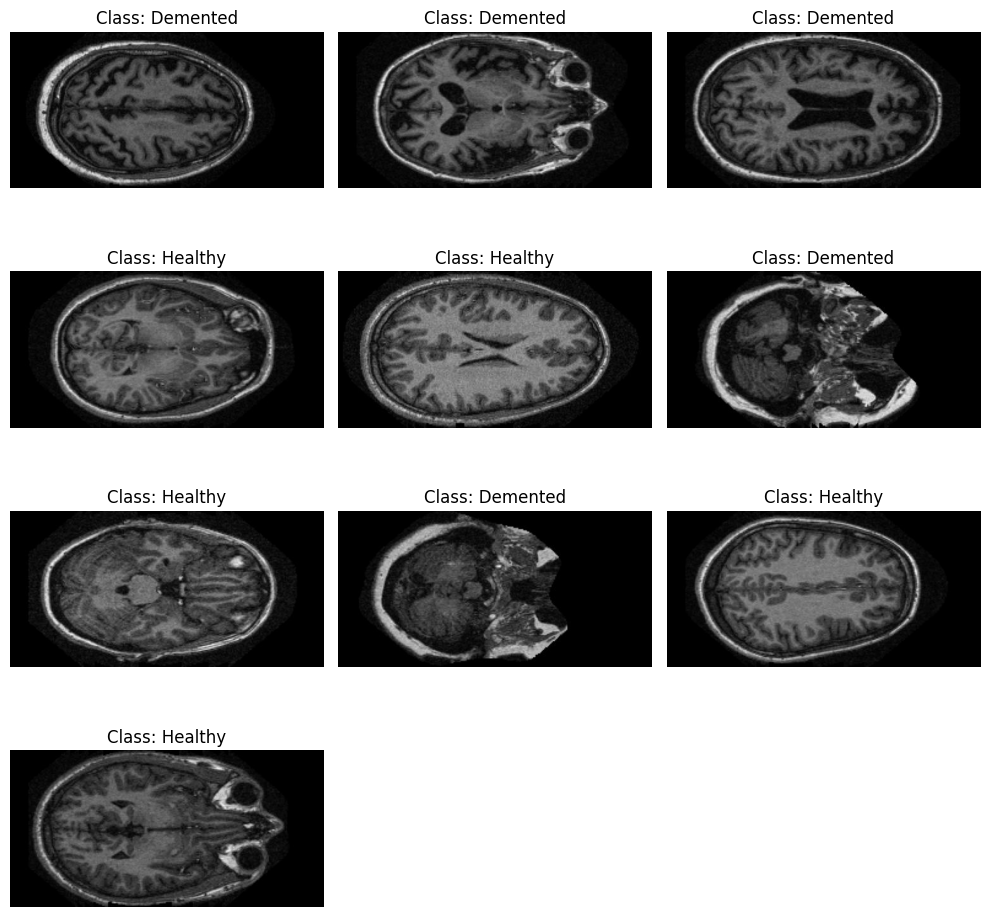

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(len(image_data)):
    img_path = image_data[i]['path']
    label = image_data[i]['label']

    # Load the image
    img = Image.open(img_path)

    # Plot the image
    plt.subplot(4, 3, i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f"Class: {label.capitalize()}")

plt.tight_layout() # Adjusts subplot params for a tighter layout
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Your file counts from the previous step
counts = {
    'Healthy Train': 53777,
    'Demented Train': 15371,
    'Healthy Test': 13445,
    'Demented Test': 3844
}

# Combine the train and test counts for a total view
total_healthy = counts['Healthy Train'] + counts['Healthy Test']
total_demented = counts['Demented Train'] + counts['Demented Test']

total_counts = {
    'Healthy': total_healthy,
    'Demented': total_demented
}

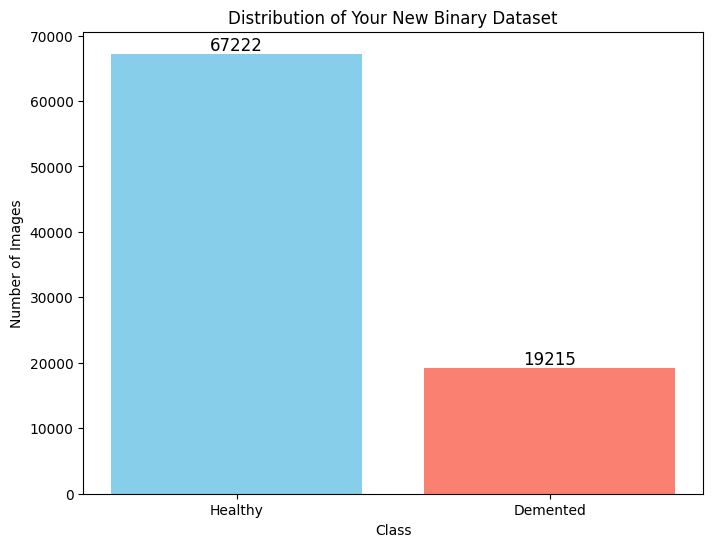

In [ ]:
# Get the labels and counts from the dictionary
labels = list(total_counts.keys())
values = list(total_counts.values())

# Create the bar chart
plt.figure(figsize=(8, 6))
plt.bar(labels, values, color=['skyblue', 'salmon'])

# Add labels and title
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Distribution of Your New Binary Dataset")

# Add the count on top of each bar
for i, v in enumerate(values):
    plt.text(i, v + 500, str(v), ha='center', fontsize=12)

# Show the plot
plt.show()

In [ ]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display a summary of the model's architecture
model.summary()

# Start the training process
print("Starting model training...")
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

# Evaluate the model on the test data
print("\nEvaluating model performance...")
loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy*100:.2f}%")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,753 (49.36 MB)

 Trainable params: 12,938,753 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

Starting model training...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2161/2161 ━━━━━━━━━━━━━━━━━━━━ 129s 57ms/step - accuracy: 0.8510 - loss: 0.3348 - val_accuracy: 0.9953 - val_loss: 0.0220
Epoch 2/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 110s 51ms/step - accuracy: 0.9868 - loss: 0.0382 - val_accuracy: 0.9967 - val_loss: 0.0099
Epoch 3/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 111s 52ms/step - accuracy: 0.9927 - loss: 0.0218 - val_accuracy: 0.9983 - val_loss: 0.0054
Epoch 4/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 111s 51ms/step - accuracy: 0.9950 - loss: 0.0144 - val_accuracy: 0.9998 - val_loss: 0.0010
Epoch 5/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 140s 50ms/step - accuracy: 0.9959 - loss: 0.0121 - val_accuracy: 0.9982 - val_loss: 0.0052
Epoch 6/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 109s 50ms/step - accuracy: 0.9973 - loss: 0.0082 - val_accuracy: 0.9990 - val_loss: 0.0031
Epoch 7/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 112s 52ms/step - accuracy: 0.9974 - loss: 0.0086 - val_accuracy: 0.9998 - val_loss: 4.5359e-04
Epoch 8/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 113s 52ms/step - accuracy: 0.9984 

Generating performance plots...


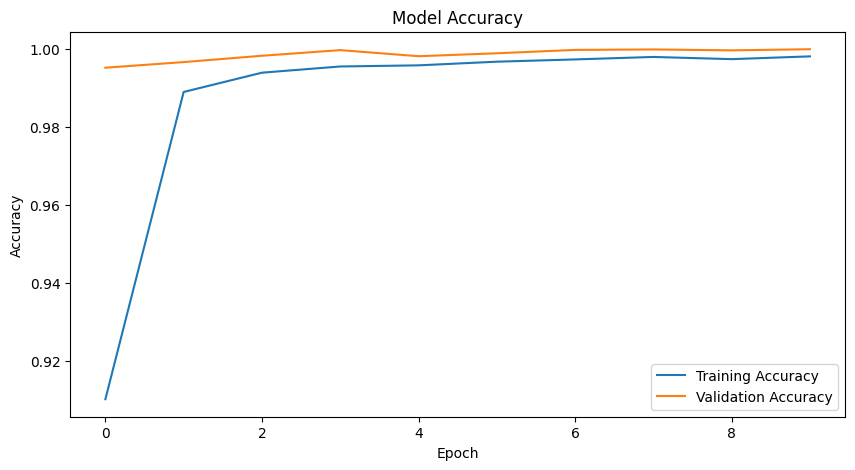

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'history' from your model.fit() command is still in memory.
# Plot training and validation accuracy
print("Generating performance plots...")
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

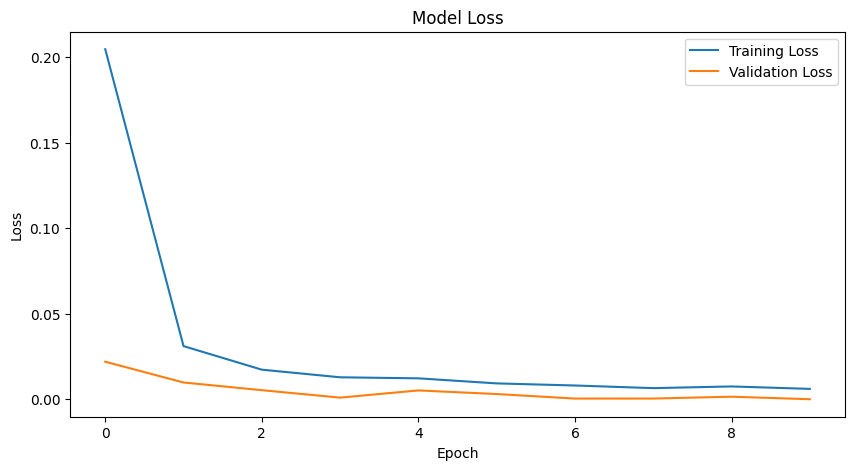

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step

Demonstrating a sample prediction with interpretation...


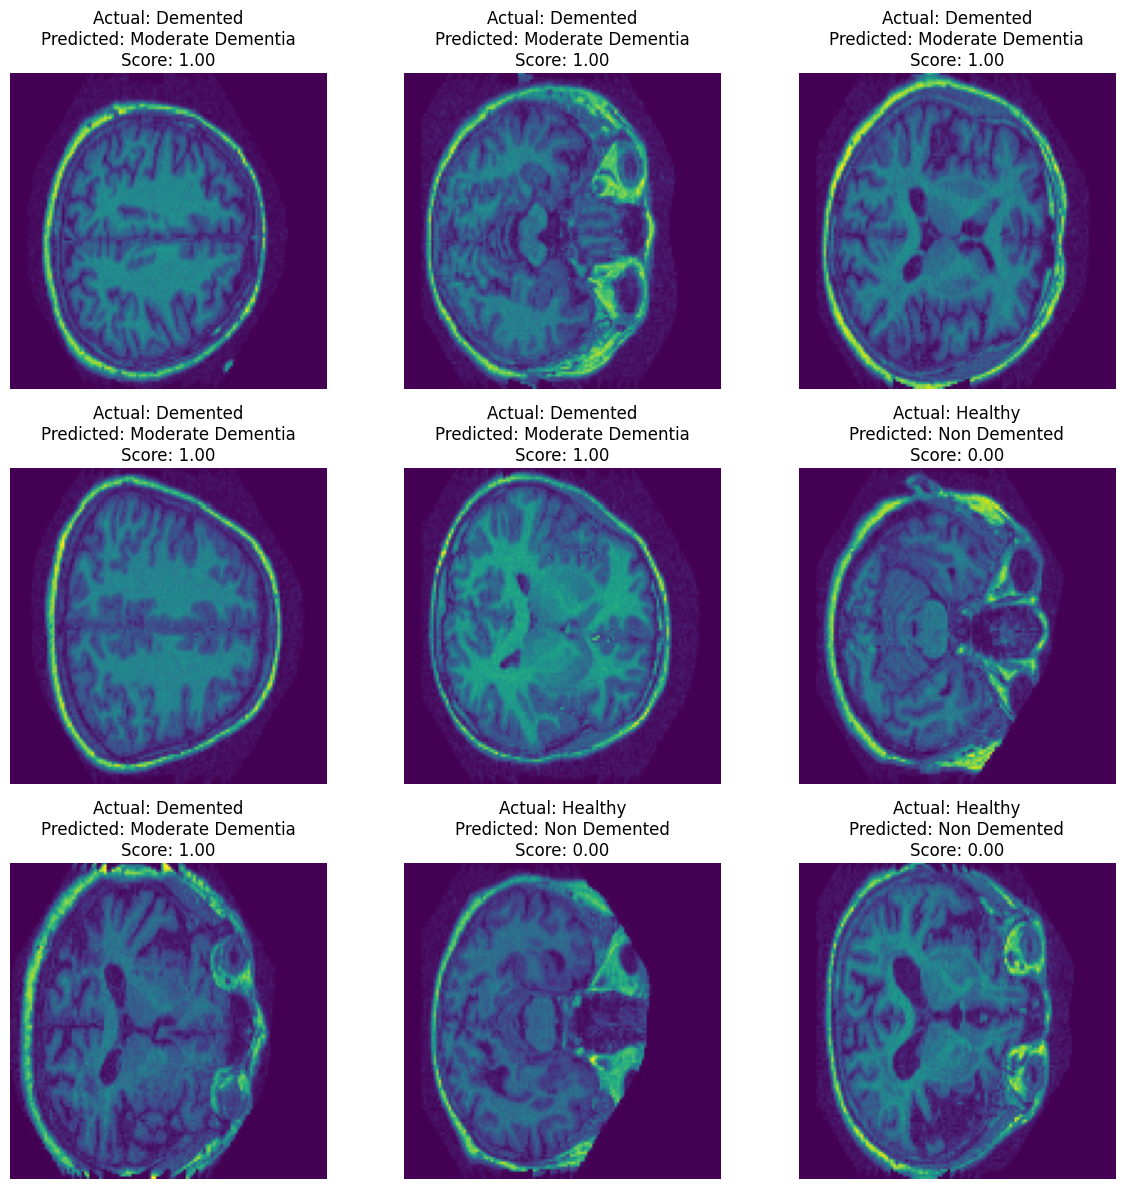

In [ ]:
import numpy as np

# The function to interpret the prediction score
def get_dementia_level(prediction_score):
    if prediction_score >= 0.8:
        return "Moderate Dementia"
    elif prediction_score >= 0.6:
        return "Mild Dementia"
    elif prediction_score >= 0.4:
        return "Very Mild Dementia"
    else:
        return "Non Demented"

# Assuming test_generator is still defined from previous steps
# Get a batch of images and true labels from the test set
x_test, y_test = next(test_generator)
y_pred_raw = model.predict(x_test)

# Display a few images with their interpreted predictions
print("\nDemonstrating a sample prediction with interpretation...")
plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i])
    plt.axis("off")

    predicted_score = y_pred_raw[i][0]
    predicted_level = get_dementia_level(predicted_score)
    actual_label = "Healthy" if y_test[i] == 0 else "Demented"

    plt.title(f"Actual: {actual_label}\nPredicted: {predicted_level}\nScore: {predicted_score:.2f}")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
# Assuming test_generator is still defined from your previous steps
# Reset the generator to get a fresh start from the beginning of the test set
test_generator.reset()

# Get the true labels
# The number of samples is the total number of images in your test set
num_samples = test_generator.samples
y_true = test_generator.classes

# Predict the labels for the entire test set
y_pred_raw = model.predict(test_generator, steps=num_samples // test_generator.batch_size + 1)
y_pred_classes = (y_pred_raw > 0.5).astype(int)

# Flatten the predicted classes array to match the shape of y_true
y_pred_classes = y_pred_classes.flatten()

541/541 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step


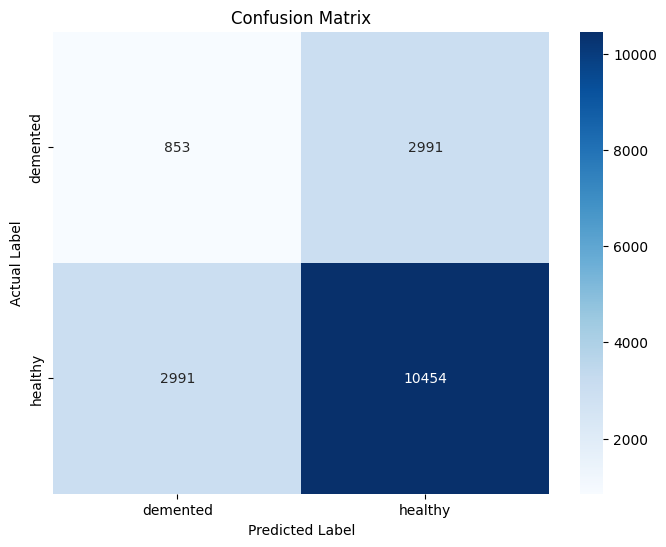

Confusion Matrix:
[[  853  2991]
 [ 2991 10454]]


In [ ]:
# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Get the class names from the generator
class_names = list(test_generator.class_indices.keys())

# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Print out the confusion matrix values for clarity
print("Confusion Matrix:")
print(cm)

In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model('alzheimer_detection_grayscale_models.h5')

# Re-compile the model with the same settings
loaded_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from PIL import Image
import numpy as np

def predict_single_image(image_path, model):
    # Load the image and resize it
    img = Image.open(image_path).resize((128, 128))
    # Convert to a numpy array and normalize
    img_array = np.array(img) / 255.0
    # Add a dimension to fit the model's input shape
    img_array = np.expand_dims(img_array, axis=0)

    # Make the prediction
    prediction = model.predict(img_array)

    return prediction[0][0]

541/541 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step


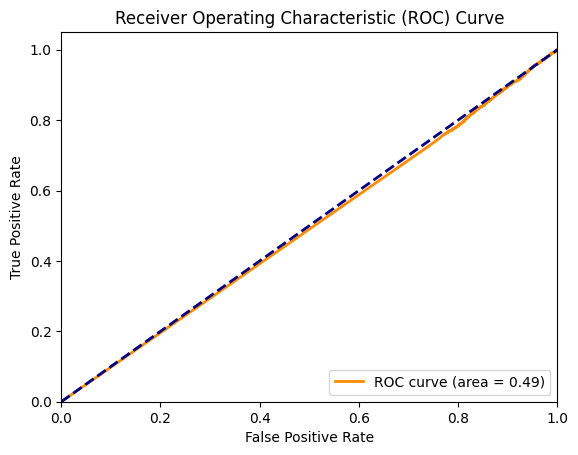

In [ ]:
from sklearn.metrics import roc_curve, auc

# Get the raw probability predictions
y_pred_proba = model.predict(test_generator).ravel()

# Get the true labels
y_true = test_generator.classes

# Calculate the ROC curve points and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
!pip install fpdf

  Preparing metadata (setup.py) ... done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=ed2c82604c5bc8979021a4e7b96acd89343b64f08ad1118334b5a084fd242b0e
  Stored in directory: /root/.cache/pip/wheels/6e/62/11/dc73d78e40a218ad52e7451f30166e94491be013a7850b5d75
Successfully built fpdf


In [ ]:
# Part 1: Final Evaluation (Run this first to get the necessary variables)
# This code assumes your model has already been trained and the `test_generator` is defined.

# Set up the paths to your new, binary data folders
new_base_dir = 'alzheimer_binary'
new_test_dir = os.path.join(new_base_dir, 'test')

# Set up the data generator for the test set
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    new_test_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False, # Important for consistent results
    color_mode='grayscale' # Important to match your model's input
)

print("Evaluating model performance...")
# Evaluate the model to get the final accuracy
loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Create the model_accuracy variable
model_accuracy = accuracy

# Get the true labels from the generator
y_true = test_generator.classes

# Get the raw predictions from the model
y_pred_raw = model.predict(test_generator)

print("-" * 50)

# Part 2: PDF Report Generation (Run this after Part 1)
# This code will now have access to the variables it needs.

# --- Step 1: Generate and Save Plots as Images ---
# Generate Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
from fpdf import FPDF

# Convert raw probabilities to binary predictions (0 or 1)
y_pred_classes = (y_pred_raw > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Demented'], yticklabels=['Healthy', 'Demented'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png')
plt.close()

# --- Step 2: Define a Sample Prediction for the Report ---
# Get a single image and its prediction from the test set
x_test_sample, y_test_sample = next(test_generator)
sample_image_array = x_test_sample[0]
sample_true_label = "Healthy" if y_test_sample[0] == 0 else "Demented"
sample_pred_score = model.predict(np.expand_dims(sample_image_array, axis=0))[0][0]

# --- Step 3: Define the Function to Interpret the Score ---
def get_dementia_level(prediction_score):
    if prediction_score >= 0.8:
        return "Moderate Dementia"
    elif prediction_score >= 0.6:
        return "Mild Dementia"
    elif prediction_score >= 0.4:
        return "Very Mild Dementia"
    else:
        return "Non Demented"

sample_predicted_level = get_dementia_level(sample_pred_score)

# --- Step 4: Create the PDF Report ---
pdf = FPDF()
pdf.add_page()
pdf.set_font('Arial', 'B', 16)
pdf.cell(200, 10, 'Alzheimer\'s Detection Report', 0, 1, 'C')

pdf.ln(10)
pdf.set_font('Arial', 'B', 14)
pdf.cell(200, 10, 'Patient Condition Analysis', 0, 1)
pdf.set_font('Arial', '', 12)
pdf.cell(200, 10, f"Predicted Condition: {sample_predicted_level}", 0, 1)
pdf.cell(200, 10, f"Prediction Score: {sample_pred_score:.2f}", 0, 1)

pdf.ln(10)
pdf.set_font('Arial', 'B', 14)
pdf.cell(200, 10, 'Model Performance Overview', 0, 1)
pdf.set_font('Arial', '', 12)
pdf.cell(200, 10, f"Overall Test Accuracy: {model_accuracy*100:.2f}%", 0, 1)

pdf.ln(5)
pdf.set_font('Arial', 'B', 12)
pdf.cell(200, 10, 'Confusion Matrix', 0, 1, 'C')
pdf.image('confusion_matrix.png', x=30, y=120, w=150)

# Save the PDF to your Colab session
pdf.output('report.pdf')

print("\nPDF report has been generated successfully as 'report.pdf'.")

Found 17289 images belonging to 2 classes.
Evaluating model performance...
541/541 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - accuracy: 1.0000 - loss: 1.1828e-04
Test Accuracy: 100.00%
541/541 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step

PDF report has been generated successfully as 'report.pdf'.


In [ ]:
# Part 1: Run the model training code first to get the trained 'model' object

# Part 2: Run this evaluation code to define the 'model_accuracy' variable
print("Evaluating model performance...")
loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Now, define the model_accuracy variable
model_accuracy = accuracy

Evaluating model performance...
541/541 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - accuracy: 1.0000 - loss: 1.1828e-04
Test Accuracy: 100.00%


In [ ]:
import os
import shutil

# Define the destination folder and filename
destination_folder = '/content/drive/MyDrive/my_models/'
filename = 'alzheimer_detection_grayscale_models.h5'  # Use the new filename
destination_path = os.path.join(destination_folder, filename)

# Create the directory if it doesn't exist
os.makedirs(destination_folder, exist_ok=True)

# Now, copy the new file to the destination
shutil.copy(filename, destination_path)

'/content/drive/MyDrive/my_models/alzheimer_detection_grayscale_models.h5'

In [ ]:
# The paths to your new, binary data folders
new_base_dir = 'alzheimer_binary'
new_train_dir = os.path.join(new_base_dir, 'train')
new_test_dir = os.path.join(new_base_dir, 'test')

# Set up the data generators with augmentation for the training set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    new_train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    color_mode='grayscale'
)

test_generator = test_datagen.flow_from_directory(
    new_test_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    color_mode='grayscale'
)

Found 69148 images belonging to 2 classes.
Found 17289 images belonging to 2 classes.


In [ ]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Calculate class weights to handle the data imbalance
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_generator.classes)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_generator.classes
)
class_weights_dict = dict(zip(classes, class_weights_array))

print("Starting model training with class weights...")
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    class_weight=class_weights_dict  # <-- Pass the calculated weights here
)

Starting model training with class weights...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 224s 102ms/step - accuracy: 0.6570 - loss: 0.7312 - val_accuracy: 0.7330 - val_loss: 0.4564
Epoch 2/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 214s 99ms/step - accuracy: 0.7632 - loss: 0.4160 - val_accuracy: 0.8193 - val_loss: 0.3435
Epoch 3/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 211s 98ms/step - accuracy: 0.7753 - loss: 0.3917 - val_accuracy: 0.7931 - val_loss: 0.3882
Epoch 4/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 231s 107ms/step - accuracy: 0.7933 - loss: 0.3679 - val_accuracy: 0.7584 - val_loss: 0.4369
Epoch 5/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 211s 98ms/step - accuracy: 0.8039 - loss: 0.3494 - val_accuracy: 0.7678 - val_loss: 0.4243
Epoch 6/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 207s 96ms/step - accuracy: 0.8126 - loss: 0.3357 - val_accuracy: 0.8222 - val_loss: 0.3559
Epoch 7/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 205s 95ms/step - accuracy: 0.8142 - loss: 0.3331 - val_accuracy: 0.7993 - val_loss: 0.3895
Epoch 8/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 206s 95ms/step - accuracy

In [ ]:
model.save('Alzheimer_detection_grayscale_final_models.h5')

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import numpy as np
import os

# Set up the data generators with augmentation for the training set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'alzheimer_binary/train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    color_mode='grayscale'
)

test_generator = test_datagen.flow_from_directory(
    'alzheimer_binary/test',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    color_mode='grayscale'
)

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Calculate class weights to handle the data imbalance
classes = np.unique(train_generator.classes)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_generator.classes
)
class_weights_dict = dict(zip(classes, class_weights_array))

print("Starting model training with class weights...")
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    class_weight=class_weights_dict
)


Found 69148 images belonging to 2 classes.
Found 17289 images belonging to 2 classes.
Starting model training with class weights...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 213s 97ms/step - accuracy: 0.4833 - loss: 0.6391 - val_accuracy: 0.7439 - val_loss: 0.4698
Epoch 2/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 208s 96ms/step - accuracy: 0.7547 - loss: 0.4443 - val_accuracy: 0.7046 - val_loss: 0.5303
Epoch 3/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 206s 95ms/step - accuracy: 0.7542 - loss: 0.4328 - val_accuracy: 0.7083 - val_loss: 0.4913
Epoch 4/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 262s 95ms/step - accuracy: 0.7579 - loss: 0.4214 - val_accuracy: 0.7214 - val_loss: 0.5019
Epoch 5/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 205s 95ms/step - accuracy: 0.7688 - loss: 0.3994 - val_accuracy: 0.6769 - val_loss: 0.5560
Epoch 6/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 208s 96ms/step - accuracy: 0.7780 - loss: 0.3830 - val_accuracy: 0.7689 - val_loss: 0.4122
Epoch 7/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 205s 95ms/step - accuracy: 0.7827 - loss: 0.3777 - val_accuracy: 0.7818 - val_loss: 0.3810
Epoch 8/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 207s 96ms/step - accuracy: 